In [1]:
from galaxy_datasets import gz_candels 
    
catalog, label_cols = gz_candels(
        root='.tmp/',
        train=True,
        download=True,
)


In [2]:
catalog.columns.to_numpy()

array(['smooth-or-featured-candels_smooth',
       'smooth-or-featured-candels_features',
       'smooth-or-featured-candels_artifact',
       'how-rounded-candels_completely', 'how-rounded-candels_in-between',
       'how-rounded-candels_cigar-shaped',
       'clumpy-appearance-candels_yes', 'clumpy-appearance-candels_no',
       'clump-count-candels_1', 'clump-count-candels_2',
       'clump-count-candels_3', 'clump-count-candels_4',
       'clump-count-candels_5-plus', 'clump-count-candels_cant-tell',
       'disk-edge-on-candels_yes', 'disk-edge-on-candels_no',
       'edge-on-bulge-candels_yes', 'edge-on-bulge-candels_no',
       'bar-candels_yes', 'bar-candels_no', 'has-spiral-arms-candels_yes',
       'has-spiral-arms-candels_no', 'spiral-winding-candels_tight',
       'spiral-winding-candels_medium', 'spiral-winding-candels_loose',
       'spiral-arm-count-candels_1', 'spiral-arm-count-candels_2',
       'spiral-arm-count-candels_3', 'spiral-arm-count-candels_4',
       'spiral

In [6]:
from ml_sandbox.dataset import load_image

im = load_image(catalog['filename'][0], dir='.tmp/')
im.mean()

AttributeError: 'JpegImageFile' object has no attribute 'mean'

In [3]:
from galaxy_datasets.pytorch.galaxy_dataset import GalaxyDataset
from torchvision.transforms import ToTensor
import torch
gzdataset = GalaxyDataset(
    catalog,
    label_cols=['merging-candels_merger'],  
    transform=ToTensor(),
    target_transform=lambda x: torch.tensor(x, dtype=torch.float32),
    )

tensor(2.)
torch.Size([3, 424, 424])


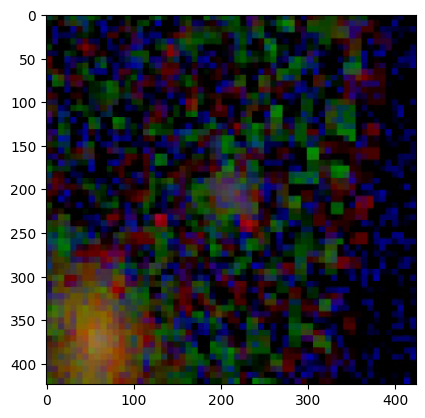

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.visualization import make_rgb, AsinhStretch
from torchvision.transforms import ToPILImage
img, labels = gzdataset[np.random.randint(len(gzdataset))]
plt.imshow(ToPILImage()(img))
print(labels)
print(img.shape)

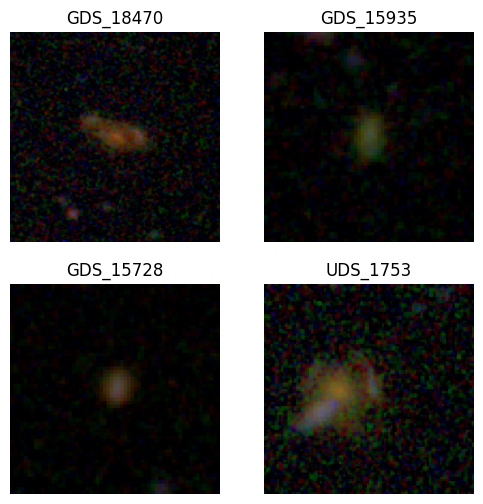

In [5]:
from ml_sandbox.dataset import show_sample_images
for i in range(3,4):
    show_sample_images(gzdataset, num_images=i+1)

In [6]:
from torch.utils.data import random_split
train_dataset, test_dataset = random_split(gzdataset, [0.8, 0.2])

In [12]:
from ml_sandbox.models import SimpleCNNClassifier
from ml_sandbox.train_eval import train_cnn, test_cnn
from ml_sandbox.dataset import get_dataloader
model = SimpleCNNClassifier(num_classes=1, input_channels=3, side=424)
train_loader = get_dataloader(train_dataset, batch_size=16)
test_loader = get_dataloader(test_dataset, batch_size=16)

from torch.nn import BCEWithLogitsLoss
criterion = BCEWithLogitsLoss()

from torch.optim import Adam
optimizer = Adam(model.parameters(), lr=1e-3)

In [13]:
for images, labels in train_loader:
    print(images.shape, labels.shape)
    print(labels)
    break

torch.Size([16, 3, 424, 424]) torch.Size([16])
tensor([ 8.,  2.,  2.,  1.,  1., 12.,  2.,  1.,  1.,  1.,  2.,  4.,  2., 11.,
         0.,  0.])


In [16]:
device = "cpu"#torch.device("cuda" if torch.cuda.is_available() else "cpu")
model=model.to(device)

In [17]:
for _ in range(5):
    train_cnn(train_loader, model, criterion, optimizer, device=device) 
    test_cnn(test_loader, model, criterion, device=device)

loss: 0.812804  [   16/31713]
loss: -38001260.000000  [ 1616/31713]
loss: -1505061888.000000  [ 3216/31713]
loss: -3851800832.000000  [ 4816/31713]


KeyboardInterrupt: 

In [18]:
for images, labels in train_loader:
    print(model(images), labels)
    break

tensor([[6.9963e+09],
        [3.4174e+09],
        [2.6189e+09],
        [6.5996e+09],
        [2.2414e+09],
        [2.6561e+09],
        [5.1489e+09],
        [1.9165e+09],
        [2.4844e+09],
        [1.3240e+10],
        [3.0722e+09],
        [2.0281e+09],
        [5.9011e+09],
        [3.7643e+09],
        [1.4227e+09],
        [3.7246e+09]], grad_fn=<AddmmBackward0>) tensor([0., 1., 5., 1., 1., 2., 0., 2., 3., 1., 2., 5., 1., 2., 0., 3.])


In [7]:
from ml_sandbox.models import make_pca_rf_pipeline
model = make_pca_rf_pipeline(n_pca_comp=150, n_trees=100, random_state=42)


In [ ]:
from ml_sandbox.dataset import split_sklearn_dataset
from sklearn.model_selection import train_test_split
xtrain, xtest, ytrain, ytest = split_sklearn_dataset(catalog, label_cols='merging-candels_merger')



In [9]:
import torchvision
from torchvision.transforms import ToTensor

In [8]:
model.fit(xtrain, ytrain)
test_accuracy = model.score(xtest, ytest)
print(f'Test Accuracy: {test_accuracy:.4f}')


ValueError: could not convert string to float: 'GDS_2171.jpg'